# Risk Measures and Portfolio Optimization

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 11 rewritten and 9 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

**Prepared by:** Madelynn Watson (mwatson4@nd.edu, 2023)

In [1]:
# Imports
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

## Introduction

A production portfolio can trade expected profit against exposure to uncertain prices. Markowitz introduced the expected-return/variance formulation in **1952**; his 1959 book developed it further. This page compares variance, mean absolute deviation (MAD), worst-case profit, VaR, and CVaR, then solves a simplified sugarcane-mill example.

Primary sources: [Markowitz (1952)](https://doi.org/10.1111/j.1540-6261.1952.tb01525.x), [Konno and Yamazaki (1991)](https://web.stanford.edu/class/msande348/papers/Konno_MeanAbDev_ManSciMay91.pdf), and [Rockafellar and Uryasev (2002)](https://sites.math.washington.edu/~rtr/papers/rtr187-CVaR2.pdf).

## Common Risk Measures for Portfolio Optimization

### Mean-Variance (MV) [1,2]

For a random return vector $\mathbf R$ with finite second moments and covariance matrix $\boldsymbol\Sigma$, the variance of $\mathbf R^T\mathbf w$ is
$$MV=\mathbf w^T\boldsymbol\Sigma\mathbf w=\sum_i\sum_j\sigma_{ij}w_iw_j.$$
Normality is not required for this identity. Variance penalizes both upside and downside dispersion and does not describe all features of an asymmetric tail. With a positive-semidefinite covariance matrix and linear constraints, the formulation is a convex quadratic program. See Markowitz (1952).

**Literature Examples Using MV**

<div class="csl-entry">Xu, D., Bai, Z., Jin, X., Yang, X., Chen, S., &#38; Zhou, M. (2022). A mean-variance portfolio optimization approach for high-renewable energy hub. <i>Applied Energy</i>, <i>325</i>. https://doi.org/10.1016/j.apenergy.2022.119888</div>


<div class="csl-entry">Chen, W., Zhang, H., Mehlawat, M. K., &#38; Jia, L. (2021). Mean–variance portfolio optimization using machine learning-based stock price prediction. <i>Applied Soft Computing</i>, <i>100</i>. https://doi.org/10.1016/j.asoc.2020.106943</div>

### Mean-Absolute Deviation (MAD) [1,3]

Konno and Yamazaki (1991) study a portfolio model that minimizes mean absolute deviation:
$$MAD=\mathbb E\left[|\mathbf R^T\mathbf w-\mathbb E[\mathbf R^T\mathbf w]|\right].$$
A finite-scenario model with linear constraints has a linear-programming reformulation using auxiliary variables for absolute deviations. It penalizes positive and negative deviations symmetrically. An LP formulation alone does not guarantee a runtime advantage for every instance.

**Graphical Representation [3]**

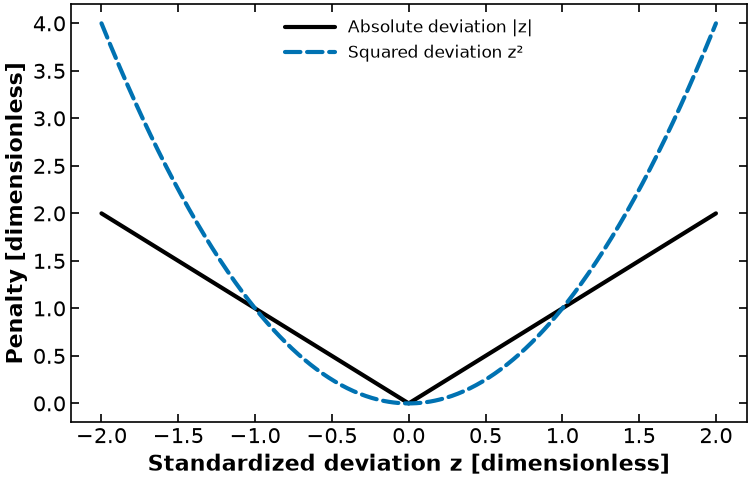

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Compare pointwise penalties on a dimensionless deviation, not a variance
# estimate: variance and MAD are expectations of these different penalties.
z = np.linspace(-2, 2, 401)
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
ax.plot(z, np.abs(z), linestyle="-", label="Absolute deviation |z|")
ax.plot(z, z**2, linestyle="--", label="Squared deviation z²")
ax.set(
    xlabel="Standardized deviation z [dimensionless]", ylabel="Penalty [dimensionless]"
)
ax.legend()
plt.show()

**Literature Examples Using MAD**

<div class="csl-entry">Hosseini-Nodeh, Z., Khanjani-Shiraz, R., &#38; Pardalos, P. M. (2023). Portfolio optimization using robust mean absolute deviation model: Wasserstein metric approach. <i>Finance Research Letters</i>. https://doi.org/10.1016/j.frl.2023.103735</div>

<div class="csl-entry">Ferreira, L., Borenstein, D., Righi, M. B., &#38; de Almeida Filho, A. T. (2018). A fuzzy hybrid integrated framework for portfolio optimization in private banking. <i>Expert Systems with Applications</i>, <i>92</i>, 350–362. https://doi.org/10.1016/j.eswa.2017.09.055</div>

### Minimax (MM) [1]

For a finite scenario set, maximize worst-case profit by introducing $v$ and imposing $v\le P_q(\mathbf x)$ for every scenario $q$. With affine profits and linear constraints, this is an LP.

It protects against the worst **modeled** scenario and can be sensitive to extreme scenarios. It is not generally equivalent to mean–variance optimization under normality: a nondegenerate normal distribution has no finite lower endpoint. Scenarios can come from a model; historical data are not a mathematical prerequisite.

**Literature Examples Using MM**

<div class="csl-entry">Li, B., Sun, Y., Aw, G., &#38; Teo, K. L. (2019). Uncertain portfolio optimization problem under a minimax risk measure. <i>Applied Mathematical Modelling</i>, <i>76</i>, 274–281. https://doi.org/10.1016/j.apm.2019.06.019</div>

<div class="csl-entry">Polak, G. G., Rogers, D. F., &#38; Sweeney, D. J. (2010). Risk management strategies via minimax portfolio optimization. <i>European Journal of Operational Research</i>, <i>207</i>(1), 409–419. https://doi.org/10.1016/j.ejor.2010.04.025</div>

### Value-at-Risk (VaR) [1,4]

Use an explicit sign convention. For loss $L$, define
$$\operatorname{VaR}_\alpha(L)=\inf\{\ell:\Pr(L\le\ell)\ge\alpha\}.$$
It is a quantile, not an average of the worst losses. Both continuous and discrete distributions have VaR; optimization involving a quantile may be nonconvex. At atoms, weak/strict inequalities matter, so a Heaviside formula with a claimed maximum can give the wrong endpoint.

Here the code models **profit** $P$ and uses $L=-P$. Profit threshold conventions must be specified separately when there are ties. See Rockafellar and Uryasev (2002).

**Literature Examples Using VaR**

<div class="csl-entry">al Janabi, M. A. M., Ferrer, R., &#38; Shahzad, S. J. H. (2019). Liquidity-adjusted value-at-risk optimization of a multi-asset portfolio using a vine copula approach. <i>Physica A: Statistical Mechanics and Its Applications</i>, <i>536</i>. https://doi.org/10.1016/j.physa.2019.122579</div>

### Conditional Value-at-Risk (CVaR) [1,4]

For integrable profit $P$ and confidence $0<\alpha<1$, the lower-tail profit measure is
$$C_\alpha(P)=\max_\nu\left\{\nu-\frac{\mathbb E[(\nu-P)_+]}{1-\alpha}\right\}=-\operatorname{CVaR}_\alpha(-P).$$
It averages the worst $1-\alpha$ **probability mass**, taking only the necessary fraction of a boundary atom. A maximizing threshold can be nonunique. This profit-oriented functional is concave; the negative-profit loss risk measure is convex and coherent. It does not report the single worst outcome.

See Rockafellar and Uryasev (2002); Birge and Louveaux (2011), 2nd ed., §2.9, pp. 85–86.

**Graphical Representation [4]**

**Check the tail definition with a discrete example.** Profits $(-100,-10,0)$ have probabilities $(0.05,0.15,0.80)$. At confidence 0.9, the worst 10% mass contains all 5% at −100 and 5% at −10. Thus lower-tail profit CVaR is $(-100\times0.05-10\times0.05)/0.1=-55$. Averaging all outcomes at or below −10 instead gives −32.5, a different quantity.

The later histograms show actual computed scenario profits, with labels and units. Expected profit is a mean; it is not a tail-risk measure.


**Literature Examples Using CVaR**

<div class="csl-entry">Mutran, V. M., Ribeiro, C. O., Nascimento, C. A. O., &#38; Chachuat, B. (2020). Risk-conscious optimization model to support bioenergy investments in the Brazilian sugarcane industry. <i>Applied Energy</i>, <i>258</i>. https://doi.org/10.1016/j.apenergy.2019.113978</div>

<div class="csl-entry">Xuan, A., Shen, X., Guo, Q., &#38; Sun, H. (2021). A conditional value-at-risk based planning model for integrated energy system with energy storage and renewables. <i>Applied Energy</i>, <i>294</i>. https://doi.org/10.1016/j.apenergy.2021.116971</div>

## Step 0: Problem statement

This teaching case is adapted from [Mutran et al. (2020)](https://repositorio.usp.br/directbitstream/6b0fa6f5-910d-42f6-a060-485e2d68c413/3013248.pdf), who study sugarcane production and investment under price uncertainty. Our continuous model fixes throughput and electricity yield, omits technology investment and detailed cogeneration, and uses constant conversion factors. It does **not** reproduce their full mixed-integer model or their published optimum. The prices and capacities are historical case data, not current market estimates.

### Problem Definition

For this problem, we model a sugarcane mill that can produce sugar, ethanol, and electricity with the ability to sell electricity to free and regulated markets. The overall capacity of the sugarcane mill is 3,000,000 tonnes of sugarcane, and conversion and cost data are provided.

### Process Flow Diagram

![Sugarcane mill: juice is split between sugar and ethanol; bagasse supports cogeneration; electricity is split between two markets.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/contrib/process_PFD.jpg)

The diagram shows process connectivity. The simplified equations below fix electricity production at 0.053 MWh per ton of cane rather than modeling a cogeneration efficiency curve.

## Step 1: Mathematical model

***Sets***
\begin{align*}
p \in P: \text{Products} \\
s \in S: Saleable\ Products \\
c \in C: Commodities \\
u \in U: Process\ Units \\
q \in Q: Historical\ Price\ Scenarios
\end{align*}

***Parameters***
\begin{align*}
Ca: Yearly\ production\ of\ sugarcane \\
\tau_{u}: Maximum\ capacity\ of\ process\ unit\ u \\
PC_{s}: Production\ cost\ of\ saleable\ product\ s \\
\theta_{f,u,p}: Conversion\ of\ resource\ f\ in\ process\ unit\ u\ to\ product\ p \\
\gamma_{u,p}: Generation\ of\ product\ p\ in\ unit\ u \\
HP_{q,c}: Historical\ Prices\ at\ price\ scenario\ q\\
\pi_{reg}: Price \ of \ electricity \ at \ the \ regulated \ market
\end{align*}

***Variables***
\begin{align*}
x_{p}: Amount\ of\ product\ p \\
profit_{q}: Profit\ for\ each\ historical\ price\ scenario\ q\\
Eprofit: Expected\ value\ of\ the\ profit
\end{align*}

***Constraints***

*Mass Balances*
\begin{align*}
x_{jui} = Ca \cdot \theta_{cane,mill,jui} \\
x_{bag} = Ca \cdot \theta_{cane,mill,bag} \\
x_{jui} = x_{jui-fact} + x_{jui-dist} \\
x_{sug} = x_{jui-fact} \cdot \theta_{jui,fact,sug} \\
x_{mol} = x_{sug} \cdot \gamma_{mol,fact} \\
x_{eth} = x_{jui-dist} \cdot \theta_{jui,dist,eth} + x_{mol} \cdot \theta_{mol,dist,eth} \\
x_{el-r} = 0.053 \cdot Ca \\
x_{reg} + x_{free} = x_{el-r}
\end{align*}

*Profit Calculations*
\begin{align*}
profit_{q} = \sum_{c \in C} x_{c} \cdot HP_{q,c} + x_{reg} \cdot \pi_{reg} - \sum_{s \in S} x_{s} \cdot PC_{s} \ \ \forall \ \ q \in Q\\
Eprofit = \frac{1}{Q} \sum_{q \in Q} profit_{q} \\ 
\end{align*}

## Step 2: Degree of freedom analysis

The implementation contains 9 resource amounts, 2 juice-split variables, $Q$ scenario profits, and one expected profit: $12+Q$ variables. Cane throughput is fixed, removing one freedom. The 8 independent physical balances, $Q$ profit definitions, and one mean-profit definition remove $Q+9$ more freedoms, leaving **2**.

Capacity inequalities and bounds can become active, but are not equality constraints in this structural count. Pyomo `Reference` aliases must not be counted as additional variables. The two physical choices are the juice split and the electricity sales split.

### Visualize Input Data

In [3]:
import logging

import pandas as pd
import numpy as np
import pyomo.environ as pyo
import matplotlib.pyplot as plt
from pyomo.environ import units as u
from pyomo.util.check_units import assert_units_consistent
from pyomo.core.base.units_container import InconsistentUnitsError

# Pyomo's unit library has tonnes, cubic meters, and MWh but no money, so declare
# a currency.
u.load_definitions_from_strings(["USD = [currency]"])

# Shorthands for the compound units this problem uses
USD_PER_TONNE = u.USD / u.metric_ton
USD_PER_M3 = u.USD / u.m**3
USD_PER_MWH = u.USD / u.MWh
M3_PER_TONNE = u.m**3 / u.metric_ton
MWH_PER_TONNE = u.MWh / u.metric_ton

In [4]:
# Load Data From CSV files stored on Github
path_cap = "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/riskmeasures_capacity.csv"
path_opex = "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/riskmeasures_opex.csv"
path_conv = "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/riskmeasures_conversions.csv"
path_gen = "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/riskmeasures_generation.csv"
path_hp = "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/riskmeasures_historicalprices.csv"
df_maxcap = pd.read_csv(path_cap)
df_prodcost = pd.read_csv(path_opex)
df_conv = pd.read_csv(path_conv)
df_gen = pd.read_csv(path_gen)
df_hp = pd.read_csv(path_hp)

In [5]:
## Uncomment to Display Additional Data in Tables
# display(df_maxcap)
# display(df_prodcost)
# display(df_conv)
# display(df_gen)

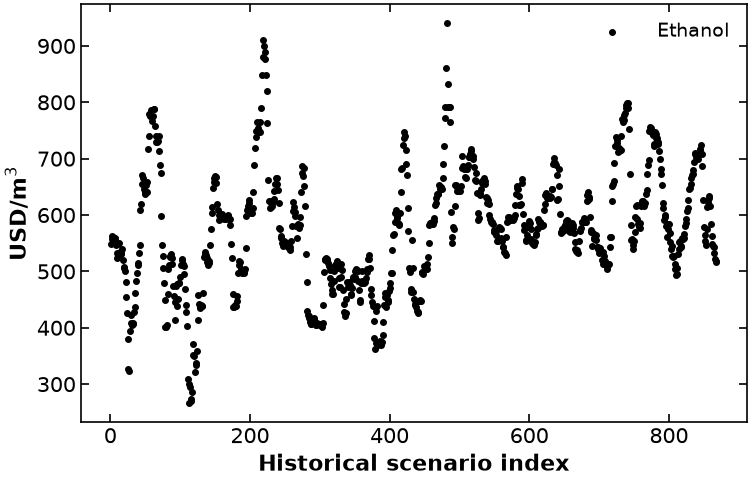

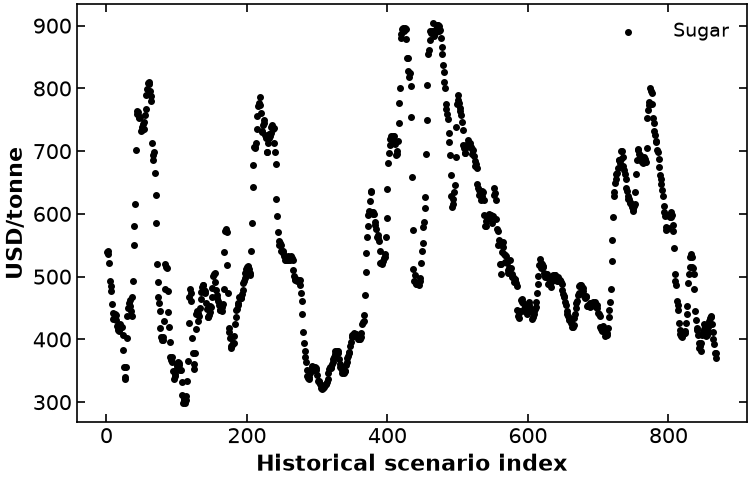

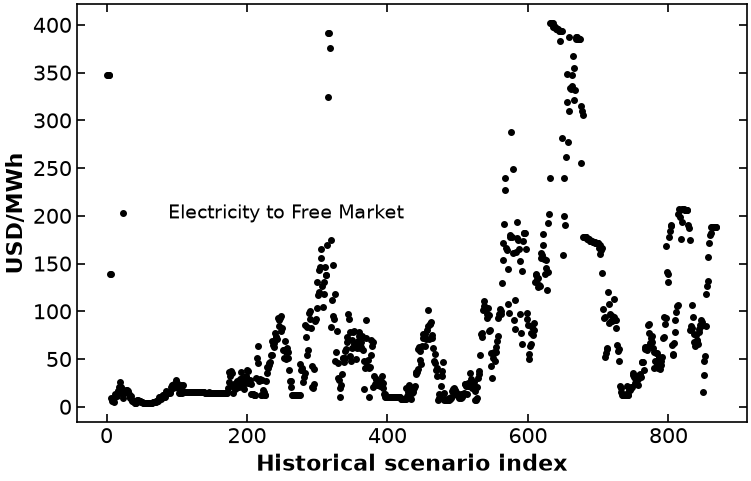

In [6]:
# Plot historical prices
x = np.arange(1, len(df_hp["eth"]) + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.scatter(x, df_hp["eth"], s=16, label="Ethanol")
plt.xlabel("Historical scenario index", fontsize=16, fontweight="bold")
plt.ylabel("USD/m$^3$", fontsize=16, fontweight="bold")
plt.legend(fontsize=14)
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.scatter(x, df_hp["sug"], s=16, label="Sugar")
plt.xlabel("Historical scenario index", fontsize=16, fontweight="bold")
plt.ylabel("USD/tonne", fontsize=16, fontweight="bold")
plt.legend(fontsize=14)
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.scatter(x, df_hp["fre"], s=16, label="Electricity to Free Market")
plt.xlabel("Historical scenario index", fontsize=16, fontweight="bold")
plt.ylabel("USD/MWh", fontsize=16, fontweight="bold")
plt.legend(fontsize=14)
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

## Step 3: Pyomo implementation

**Units.** This mill sells three commodities measured in three different physical
dimensions: sugar in tonnes, ethanol in cubic meters, and electricity in MWh. Pyomo
attaches units to a *component*, not to an index, so one `Var` indexed over all nine
resources cannot carry them. The builder below declares one variable per dimension
and stitches them back together with `pyo.Reference`, so the rest of the notebook can
still write `m.amount["eth"]`. Each completed objective model is checked with `assert_units_consistent`, which
raises if any constraint or the objective does not balance. A units declaration
nobody checks only looks verified.

In [7]:
# Create Base Model In Pyomo
def create_model(
    capacity_data=df_maxcap,
    cost_data=df_prodcost,
    conversion_data=df_conv,
    generation_data=df_gen,
    price_data=df_hp,
):
    """
    This function builds a superstructure model in Pyomo for a sugarcane mill that
    can produce sugar, ethanol, and electricity.

    Args: capacity, cost, conversion, generation and price DataFrames.
    Returns: a fresh Pyomo model; amounts are annual totals and profit is USD.
    """
    m = pyo.ConcreteModel()

    # SETS
    resources = ["sug", "eth", "fre", "reg", "cane", "jui", "mol", "bag", "el-r"]
    saleable_products = ["sug", "eth", "fre", "reg"]
    processes = ["mill", "fact", "dist", "cogen"]
    commodity = ["fre", "sug", "eth"]

    # The nine resources are measured in three different physical dimensions.
    mass = ["sug", "cane", "jui", "mol", "bag"]  # tonne
    volume = ["eth"]  # m3
    energy = ["fre", "reg", "el-r"]  # MWh

    # Price of each saleable product carries the matching units
    price_units = {
        "sug": USD_PER_TONNE,
        "eth": USD_PER_M3,
        "fre": USD_PER_MWH,
        "reg": USD_PER_MWH,
    }

    # PARAMETERS
    # Scalars
    Ca = 3000000 * u.metric_ton  # Annual Sugarcane Capacity
    price_reg = 72.5 * USD_PER_MWH  # Price of electricity sold to the regulated market

    # Fill in Dictionaries with Excel Data
    max_cap = {}
    prodcost = {}
    conv = {}
    gen = {}
    hp = {}

    for i in range(len(capacity_data["process"])):
        max_cap[capacity_data["process"][i]] = (
            capacity_data["capacity"][i] * u.metric_ton
        )

    for i in range(len(cost_data["saleable_product"])):
        s = cost_data["saleable_product"][i]
        prodcost[s] = cost_data["cost"][i] * price_units[s]

    for k in resources:
        for i in range(len(conversion_data[k])):
            conv[(conversion_data["resource"][i], conversion_data["process"][i], k)] = (
                conversion_data[k][i]
            )

    for k in resources:
        for i in range(len(generation_data[k])):
            gen[(generation_data["process"][i], k)] = generation_data[k][i]

    for k in commodity:
        for i in range(len(price_data[k])):
            hp[(price_data["q"][i], k)] = price_data[k][i] * price_units[k]

    N = len(price_data["q"])
    q = []
    for i in range(1, N + 1):
        q.append("t%d" % (i))

    # PYOMO SETS
    m.RESOURCES = pyo.Set(initialize=resources)
    m.SALEABLE_PRODUCTS = pyo.Set(initialize=saleable_products)
    m.PROCESSES = pyo.Set(initialize=processes)
    m.PRICE_SCENARIOS = pyo.Set(initialize=q)
    m.COMMODITIES = pyo.Set(initialize=commodity)

    m.n_scenarios = pyo.Param(initialize=N)

    m.MASS = pyo.Set(initialize=mass)
    m.VOLUME = pyo.Set(initialize=volume)
    m.ENERGY = pyo.Set(initialize=energy)

    # VARIABLES
    # Positive Variables. Pyomo attaches units to a component, not to an index, so
    # the amount of each resource needs one variable per physical dimension.
    m.amount_mass = pyo.Var(m.MASS, domain=pyo.NonNegativeReals, units=u.metric_ton)
    m.amount_volume = pyo.Var(m.VOLUME, domain=pyo.NonNegativeReals, units=u.m**3)
    m.amount_energy = pyo.Var(m.ENERGY, domain=pyo.NonNegativeReals, units=u.MWh)

    # ... and a Reference stitches the three back into a single indexed view, so
    # the rest of the notebook can write m.amount["eth"] regardless of dimension.
    m.amount = pyo.Reference(
        {
            **{i: m.amount_mass[i] for i in mass},
            **{i: m.amount_volume[i] for i in volume},
            **{i: m.amount_energy[i] for i in energy},
        },
        ctype=pyo.Var,
    )

    # Juice split between the factory and the distillery
    m.JUICE_DESTINATIONS = pyo.Set(initialize=["fact", "dist"])
    m.amount["cane"].fix(3000000)  # Fixed annual throughput; not a free decision.
    m.juice_split = pyo.Var(
        m.JUICE_DESTINATIONS, domain=pyo.NonNegativeReals, units=u.metric_ton
    )
    m.profit = pyo.Var(m.PRICE_SCENARIOS, units=u.USD)
    m.expected_profit = pyo.Var(units=u.USD)

    # CONSTRAINTS
    # Superstructure Constraints
    @m.Constraint()
    def juice_yield(b):
        return b.amount["jui"] == Ca * conv["cane", "mill", "jui"]

    @m.Constraint()
    def bagasse_yield(b):
        return b.amount["bag"] == Ca * conv["cane", "mill", "bag"]

    @m.Constraint()
    def juice_balance(b):
        return b.amount["jui"] == b.juice_split["fact"] + b.juice_split["dist"]

    @m.Constraint()
    def factory_capacity(b):
        return b.juice_split["fact"] <= max_cap["fact"]

    @m.Constraint()
    def distillery_capacity(b):
        return b.juice_split["dist"] <= max_cap["dist"]

    @m.Constraint()
    def sugar_yield(b):
        return b.amount["sug"] == conv["jui", "fact", "sug"] * b.juice_split["fact"]

    @m.Constraint()
    def molasses_yield(b):
        return b.amount["mol"] == gen["fact", "mol"] * b.amount["sug"]

    @m.Constraint()
    def ethanol_yield(b):
        return (
            b.amount["eth"]
            == conv["jui", "dist", "eth"] * M3_PER_TONNE * b.juice_split["dist"]
            + conv["mol", "dist", "eth"] * M3_PER_TONNE * b.amount["mol"]
        )

    @m.Constraint()
    def el_produced(b):
        # 53 kWh produced per tonne of sugarcane processed
        return b.amount["el-r"] == Ca * 0.053 * MWH_PER_TONNE

    @m.Constraint()
    def electricity(b):
        return b.amount["fre"] + b.amount["reg"] == b.amount["el-r"]

    # Expected Profit
    @m.Constraint(m.PRICE_SCENARIOS)
    def scenario_profit(b, q):
        return b.profit[q] == b.amount["sug"] * hp[q, "sug"] + b.amount["eth"] * hp[
            q, "eth"
        ] + b.amount["fre"] * hp[q, "fre"] + b.amount["reg"] * price_reg - sum(
            b.amount[j] * prodcost[j] for j in b.SALEABLE_PRODUCTS
        )

    @m.Constraint()
    def mean_profit(b):
        return b.expected_profit == (1 / N) * sum(
            b.profit[q] for q in b.PRICE_SCENARIOS
        )

    # Monetary exposure. The mean historical price of each commodity is the
    # conversion factor that puts tonnes, cubic meters, and MWh on one basis:
    # exposure[c] is the revenue exposed to the price of commodity c, in USD.
    p_bar = {c: price_data[c].mean() * price_units[c] for c in commodity}

    def exposure(m, c):
        return p_bar[c] * m.amount[c]

    m.exposure = pyo.Expression(m.COMMODITIES, rule=exposure)

    # Product Revenues to be used in analysis
    def sug_prof(m):
        return sum(m.amount["sug"] * hp[q, "sug"] for q in m.PRICE_SCENARIOS) * (1 / N)

    m.avg_sug_prof = pyo.Expression(rule=sug_prof)

    def eth_prof(m):
        return sum(m.amount["eth"] * hp[q, "eth"] for q in m.PRICE_SCENARIOS) * (1 / N)

    m.avg_eth_prof = pyo.Expression(rule=eth_prof)

    def el_prof(m):
        return sum(m.amount["fre"] * hp[q, "fre"] for q in m.PRICE_SCENARIOS) * (1 / N)

    m.avg_el_prof = pyo.Expression(rule=el_prof)

    return m

## Step 4: Analyze results

### Maximize expected profit

In [8]:
# Load the base model from the function created above
m = create_model()


# Set the objective to maximize the expected value of the profit
@m.Objective(sense=pyo.maximize)
def objective(b):
    return b.expected_profit


# Every constraint and the objective must balance dimensionally
assert_units_consistent(m)

# Solve the Model
sol = pyo.SolverFactory("appsi_highs")

results = sol.solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print("Results")
print("----------------------------------------------------")
print("Expected Profit", np.round(pyo.value(m.objective), 2), "USD")
print("Ethanol Produced", np.round(pyo.value(m.amount["eth"]), 2), "m3")
print("Sugar Produced", np.round(pyo.value(m.amount["sug"]), 2), "tonne")
print("Electricity Produced", np.round(pyo.value(m.amount["el-r"]), 2), "MWh")
print("Electricity to Free Market", np.round(pyo.value(m.amount["fre"]), 2), "MWh")
print("Electricity to Regulated Market", np.round(pyo.value(m.amount["reg"]), 2), "MWh")

Results
----------------------------------------------------
Expected Profit 64780608.39 USD
Ethanol Produced 155062.24 m3
Sugar Produced 189129.78 tonne
Electricity Produced 159000.0 MWh
Electricity to Free Market 159000.0 MWh
Electricity to Regulated Market 0.0 MWh


### Visualize Results

**Profit Distribution**

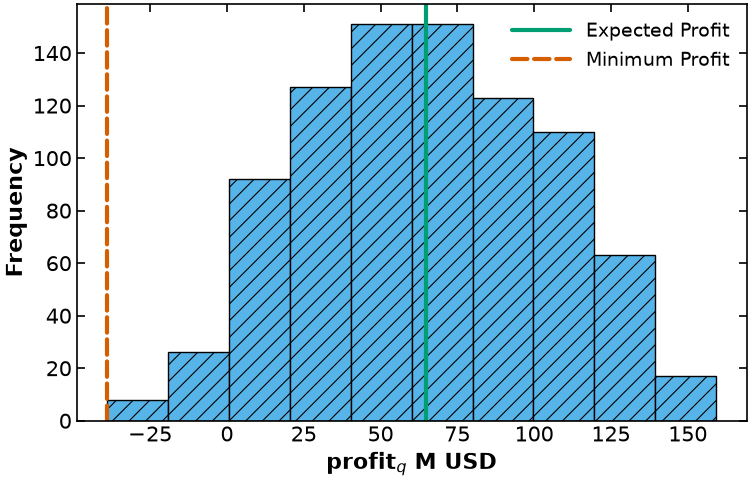

Results
-------------------------------------
Expected Profit: 64.78 M USD
Minimum Profit: -39.0 M USD
Difference: 103.78 M USD


In [9]:
# Collect the profit distribution
profits = []
for i in m.PRICE_SCENARIOS:
    profits.append(pyo.value(m.profit[i]))

# Collect the minimum profit
min_prof = min(profits)

# Plot the Profit Distribution
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.hist(np.array(profits) / 1e6, color="#56B4E9", edgecolor="black", hatch="//")
plt.axvline(
    x=pyo.value(m.objective) / 1e6,
    label="Expected Profit",
    color="#009E73",
    linestyle="solid",
    linewidth=3,
)
plt.axvline(
    x=min_prof / 1e6,
    label=("Minimum Profit"),
    color="#D55E00",
    linestyle="dashed",
    linewidth=3,
)
plt.xlabel("profit$_q$ M USD", fontsize=16, fontweight="bold")
plt.ylabel("Frequency", fontsize=16, fontweight="bold")
plt.legend(fontsize=14)
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

print("Results")
print("-------------------------------------")
print("Expected Profit:", np.round(pyo.value(m.objective) / 1e6, 2), "M USD")
print("Minimum Profit:", np.round(min_prof / 1e6, 2), "M USD")
difference = pyo.value(m.objective) - min_prof
print("Difference:", np.round(difference / 1e6, 2), "M USD")

# Collect Results for Conclusion
final_EP = {}
final_min = {}
final_diff = {}
final_exposure = {}
final_profits = {}

final_EP["No Risk"] = pyo.value(m.objective) / 1e6
final_min["No Risk"] = min_prof / 1e6
final_diff["No Risk"] = difference / 1e6
final_exposure["No Risk"] = {c: pyo.value(m.exposure[c]) for c in m.COMMODITIES}
final_profits["No Risk"] = np.array(profits)

**Product Distribution**

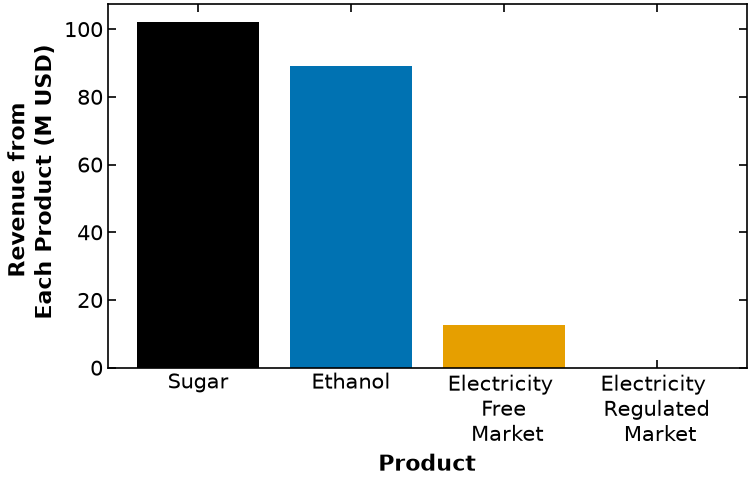

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.bar("Sugar", pyo.value(m.avg_sug_prof) / 1e6)
plt.bar("Ethanol", pyo.value(m.avg_eth_prof) / 1e6)
plt.bar("Electricity \n Free \n Market", pyo.value(m.avg_el_prof) / 1e6)
plt.bar("Electricity \n Regulated \n Market", pyo.value(m.amount["reg"]) * 72.5 / 1e6)
plt.xlabel("Product", fontsize=16, fontweight="bold")
plt.ylabel("Revenue from \n Each Product (M USD)", fontsize=16, fontweight="bold")
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

### Solve with risk measures

Use an expected-profit floor $\rho$ and minimize the chosen risk measure subject to $\mathbb E[P]\ge\rho$ (or maximize lower-tail profit CVaR).

A global optimum is weakly Pareto efficient; ties can require a secondary objective to select a strongly efficient point. A finite sweep samples tradeoffs, not the entire frontier. An inactive return inequality does not remove a degree of freedom. Weighted sums can recover supported tradeoffs; they may miss unsupported Pareto points in a nonconvex objective image.

All three models below use the same expected-profit floor, but MV/MAD use **price-return shocks on mean-price exposures**, while CVaR uses **profit under price-level scenarios**. Comparing them therefore changes both the risk functional and the random quantity being measured.

In [11]:
# The maximum attainable expected profit. This is the top of every frontier
# below, and it sets the scale for the required return rho.
sol = pyo.SolverFactory("appsi_highs")

m = create_model()
m.objective = pyo.Objective(expr=m.expected_profit, sense=pyo.maximize)
results = sol.solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)
EP_max = pyo.value(m.expected_profit)

# Required return for the three risk measures below: 95% of the maximum, so we
# are willing to give up 5% of the expected profit to buy a reduction in risk.
rho_required = 0.95 * EP_max

print("Maximum expected profit :", np.round(EP_max / 1e6, 3), "M USD")
print("Required return (rho)   :", np.round(rho_required / 1e6, 3), "M USD")


def add_required_return(m, rho):
    """Attach the epsilon-constraint Eprofit >= rho to a model.

    Args:
        m: a Pyomo model from create_model()
        rho: required expected profit [USD]
    """
    m.required_return = pyo.Constraint(expr=m.expected_profit >= rho * u.USD)


def initialize_from_max_profit(m):
    """Solve the expected-profit problem and leave its solution in m.

    This optional warm start is not required by the HiGHS LP solver.

    Args:
        m: a Pyomo model from create_model()
    """
    m.init_obj = pyo.Objective(expr=m.expected_profit, sense=pyo.maximize)
    results = pyo.SolverFactory("appsi_highs").solve(m)
    assert pyo.check_optimal_termination(results), (
        f"Initialization solve failed: status={results.solver.status}, "
        f"termination={results.solver.termination_condition}"
    )
    m.init_obj.deactivate()

Maximum expected profit : 64.781 M USD
Required return (rho)   : 61.542 M USD


### Formulate the MV Objective

***Additional Parameters***
\begin{align*}
\sigma_{i,j}: \ Covariance \ matrix \ between \ returns \ i \ and \ j \in \ commodities \\
\bar{p}_{c}: \ Mean \ historical \ price \ of \ commodity \ c \\
\rho: \ Required \ expected \ profit
\end{align*}

***Calculating Returns from Historical Price Data***
\begin{align*}
r^{lin} & = \frac{HP_{q+\Delta q} - HP_q}{HP_q}  \ for \ c \in C
\end{align*}

***Monetary Exposure***
\begin{align*}
w_{c} = \bar{p}_{c} \cdot x_{c} \ \ \forall \ \ c \in C
\end{align*}

***Objective***
\begin{align*}
minimize \ MV = \sum_{i=1}^{n} \sum_{j=1}^{n} \sigma_{i,j} w_i w_j \\
s.t. \ \ Eprofit \geq \rho
\end{align*}

```{note}
**Why $w_c$ and not $x_c$?** In the monetary-exposure convention, $w_i$ is the money exposed to asset $i$,
so $\sigma_{i,j} x_i x_j$ has units of currency squared. Here $x_c$ is *physical
production* --- tonnes, cubic meters, and MWh --- and the covariance is of
dimensionless price returns, so $\sum_{i,j} \sigma_{i,j} x_i x_j$ would add
tonne$^2$ to m$^6$ to MWh$^2$. Multiplying by the mean price $\bar{p}_c$ puts every
commodity on a common monetary basis: $w_c$ is the revenue exposed to the price of
commodity $c$, in USD, and $MV$ comes out in USD$^2$ --- the right dimension for the
variance of a quantity of money. Its square root is a standard deviation in USD,
in the same units as $MAD$ and $CVaR$ below. Equal units do not make the underlying random quantities identical.
```

**Calculate the Covariance Matrix**

In [12]:
# Calculate the Covariance Matrix

# Drop the scenario number column
price = df_hp.drop(columns=["q"])

# Calculate price_returns
price_returns = price.diff() / price.shift(1)

covar = price_returns.cov()
print("Covariance Matrix")
print("-------------------")
print(covar)

Covariance Matrix
-------------------
          fre       sug       eth
fre  0.094993 -0.000350 -0.000756
sug -0.000350  0.000922  0.000390
eth -0.000756  0.000390  0.001578


**The Units Check Bites**

In [13]:
# Build MV over the raw production variables -- the dimensionally incoherent
# version -- and Pyomo refuses it before any solver is called.
m_bad = create_model()
m_bad.objective = pyo.Objective(
    expr=sum(
        m_bad.amount[i] * covar.loc[i, j] * m_bad.amount[j]
        for i in m_bad.COMMODITIES
        for j in m_bad.COMMODITIES
    ),
    sense=pyo.minimize,
)

# Pyomo also logs the offending expression; the exception below says it all.
logger = logging.getLogger("pyomo.util.check_units")
logger.setLevel(logging.CRITICAL)

try:
    assert_units_consistent(m_bad)
    print("No error -- this should not happen!")
except InconsistentUnitsError as e:
    print("InconsistentUnitsError:", e)

logger.setLevel(logging.WARNING)

InconsistentUnitsError: Error in units found in expression: 0.09499265505563526*amount_energy[fre]*amount_energy[fre] - 0.0003500722699504732*amount_energy[fre]*amount_mass[sug] - 0.0007555516171915655*amount_energy[fre]*amount_volume[eth] - 0.0003500722699504732*amount_mass[sug]*amount_energy[fre] + 0.0009217779801648573*amount_mass[sug]*amount_mass[sug] + 0.00039027914171650425*amount_mass[sug]*amount_volume[eth] - 0.0007555516171915655*amount_volume[eth]*amount_energy[fre] + 0.00039027914171650425*amount_volume[eth]*amount_mass[sug] + 0.0015784904740984824*amount_volume[eth]*amount_volume[eth]: megawatt_hour ** 2 not compatible with megawatt_hour * metric_ton.


In [14]:
# Reload the base Model
m = create_model()

# The epsilon-constraint: this portfolio must earn at least rho in expectation
add_required_return(m, rho_required)


# Define MV as the objective. This is written over the monetary exposures
# w_c = pbar_c * x_c, so every term is in USD^2.
@m.Objective(sense=pyo.minimize)
def objective(b):
    return sum(
        b.exposure[i] * covar.loc[i, j] * b.exposure[j]
        for i in b.COMMODITIES
        for j in b.COMMODITIES
    )


assert_units_consistent(m)

# Solve the Model
sol = pyo.SolverFactory("ipopt")

results = sol.solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print("Results")
print("--------------------------------------")
print("MV", "%.4g" % pyo.value(m.objective), "USD^2")
print("sqrt(MV)", np.round(np.sqrt(pyo.value(m.objective)) / 1e6, 2), "M USD")
print("Expected Profit", np.round(pyo.value(m.expected_profit), 2), "USD")
print("Required Return", np.round(rho_required, 2), "USD")
print("Ethanol Produced", np.round(pyo.value(m.amount["eth"]), 2), "m3")
print("Sugar Produced", np.round(pyo.value(m.amount["sug"]), 2), "tonne")
print("Electricity Produced", np.round(pyo.value(m.amount["el-r"]), 2), "MWh")
print("Electricity to Free Market", np.round(pyo.value(m.amount["fre"]), 2), "MWh")
print("Electricity to Regulated Market", np.round(pyo.value(m.amount["reg"]), 2), "MWh")

Results
--------------------------------------
MV 2.904e+13 USD^2
sqrt(MV) 5.39 M USD
Expected Profit 61541577.36 USD
Required Return 61541577.97 USD
Ethanol Produced 163286.44 m3
Sugar Produced 175592.77 tonne
Electricity Produced 159000.0 MWh
Electricity to Free Market 14099.97 MWh
Electricity to Regulated Market 144900.03 MWh


### Visualize Results

**Profit Distribution**

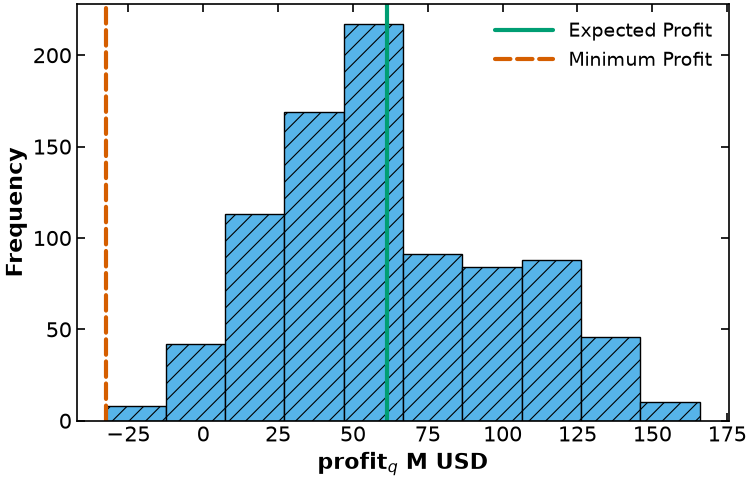

Results
-------------------------------------
Expected Profit: 61.54 M USD
Minimum Profit: -32.36 M USD
Difference: 93.91 M USD


In [15]:
# Collect the profit distribution
profits = []
for i in m.PRICE_SCENARIOS:
    profits.append(pyo.value(m.profit[i]))

# Collect the minimum profit
min_prof = min(profits)

# Plot the Profit Distribution
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.hist(np.array(profits) / 1e6, color="#56B4E9", edgecolor="black", hatch="//")
plt.axvline(
    x=pyo.value(m.expected_profit) / 1e6,
    label="Expected Profit",
    color="#009E73",
    linestyle="solid",
)
plt.axvline(
    x=min_prof / 1e6,
    label=("Minimum Profit"),
    color="#D55E00",
    linestyle="dashed",
)
plt.xlabel("profit$_q$ M USD", fontsize=16, fontweight="bold")
plt.ylabel("Frequency", fontsize=16, fontweight="bold")
plt.legend(fontsize=14)
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

print("Results")
print("-------------------------------------")
print("Expected Profit:", np.round(pyo.value(m.expected_profit) / 1e6, 2), "M USD")
print("Minimum Profit:", np.round(min_prof / 1e6, 2), "M USD")
difference = pyo.value(m.expected_profit) - min_prof
print("Difference:", np.round(difference / 1e6, 2), "M USD")

# Collect results for conclusion
final_EP["MV"] = pyo.value(m.expected_profit) / 1e6
final_min["MV"] = min_prof / 1e6
final_diff["MV"] = difference / 1e6
final_exposure["MV"] = {c: pyo.value(m.exposure[c]) for c in m.COMMODITIES}
final_profits["MV"] = np.array(profits)

**Product Distribution**

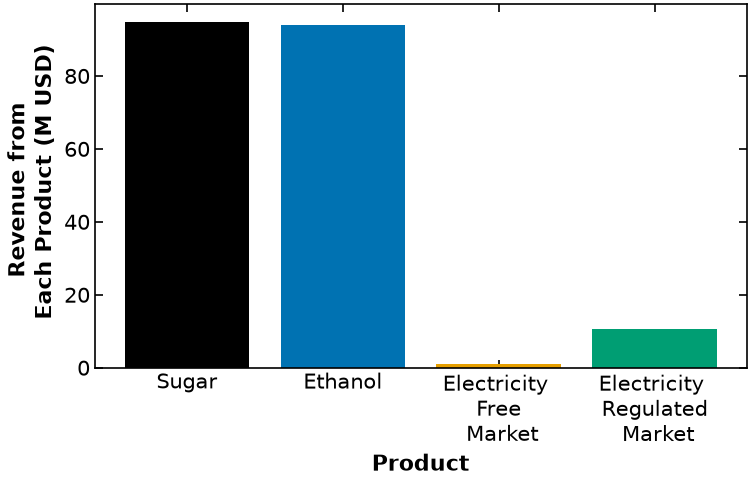

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.bar("Sugar", pyo.value(m.avg_sug_prof) / 1e6)
plt.bar("Ethanol", pyo.value(m.avg_eth_prof) / 1e6)
plt.bar("Electricity \n Free \n Market", pyo.value(m.avg_el_prof) / 1e6)
plt.bar("Electricity \n Regulated \n Market", pyo.value(m.amount["reg"]) * 72.5 / 1e6)
plt.xlabel("Product", fontsize=16, fontweight="bold")
plt.ylabel("Revenue from \n Each Product (M USD)", fontsize=16, fontweight="bold")
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

### Formulate the MAD Objective

\begin{align*}
minimize \ \ MAD = E \left[ \mid \sum_{j=1}^{n} R_j w_j -E \left[ \sum_{j=1}^{n} R_j w_j \right] \mid \right] \\
s.t. \ \ Eprofit \geq \rho
\end{align*}


In [17]:
# Reload the base Model
m = create_model()

# An optional warm start; the LP solver does not require it.
initialize_from_max_profit(m)

# Create set of return indices.  price_returns.loc[0] is NaN -- the first week has
# no previous week to difference against -- so the deviations run over 1..n_scenarios-1.
J = np.arange(1, m.n_scenarios)
n_returns = len(J)

# Mean return of each commodity over those n_returns observations.  Dividing
# the sum by m.n_scenarios instead of n_returns would use the wrong sample size.
mean_return = {c: price_returns.loc[J, c].mean() for c in m.COMMODITIES}

# Create new variables. The deviations are monetary, like the exposures.
m.RETURN_OBSERVATIONS = pyo.Set(initialize=J)
m.y_aux = pyo.Var(m.RETURN_OBSERVATIONS, domain=pyo.NonNegativeReals, units=u.USD)
m.z_aux = pyo.Var(m.RETURN_OBSERVATIONS, domain=pyo.NonNegativeReals, units=u.USD)


# Constrain y - z to be the abs portion
@m.Constraint(m.RETURN_OBSERVATIONS)
def aux(b, j):
    return b.y_aux[j] - b.z_aux[j] == sum(
        b.exposure[i] * (price_returns.loc[j, i] - mean_return[i])
        for i in b.COMMODITIES
    )


# Initialize the deviations from the exposures we already have
for j in J:
    dev = sum(
        pyo.value(m.exposure[i]) * (price_returns.loc[j, i] - mean_return[i])
        for i in m.COMMODITIES
    )
    m.y_aux[j].set_value(max(0.0, dev))
    m.z_aux[j].set_value(max(0.0, -dev))

# The epsilon-constraint: this portfolio must earn at least rho in expectation
add_required_return(m, rho_required)


# Define MAD as the objective
@m.Objective(sense=pyo.minimize)
def objective(b):
    return (1 / n_returns) * sum(b.y_aux[j] + b.z_aux[j] for j in J)


assert_units_consistent(m)

# Solve the Model
sol = pyo.SolverFactory("appsi_highs")

results = sol.solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print("Results")
print("------------------------------")
print("MAD", np.round(pyo.value(m.objective) / 1e6, 2), "M USD")
print("Expected Profit", np.round(pyo.value(m.expected_profit), 2), "USD")
print("Required Return", np.round(rho_required, 2), "USD")
print("Ethanol Produced", np.round(pyo.value(m.amount["eth"]), 2), "m3")
print("Sugar Produced", np.round(pyo.value(m.amount["sug"]), 2), "tonne")
print("Electricity Produced", np.round(pyo.value(m.amount["el-r"]), 2), "MWh")
print("Electricity to Free Market", np.round(pyo.value(m.amount["fre"]), 2), "MWh")
print("Electricity to Regulated Market", np.round(pyo.value(m.amount["reg"]), 2), "MWh")

Results
------------------------------
MAD 3.61 M USD
Expected Profit 61541577.97 USD
Required Return 61541577.97 USD
Ethanol Produced 163217.88 m3
Sugar Produced 175705.63 tonne
Electricity Produced 159000.0 MWh
Electricity to Free Market 10856.52 MWh
Electricity to Regulated Market 148143.48 MWh


### Visualize Results

**Profit Distribution**

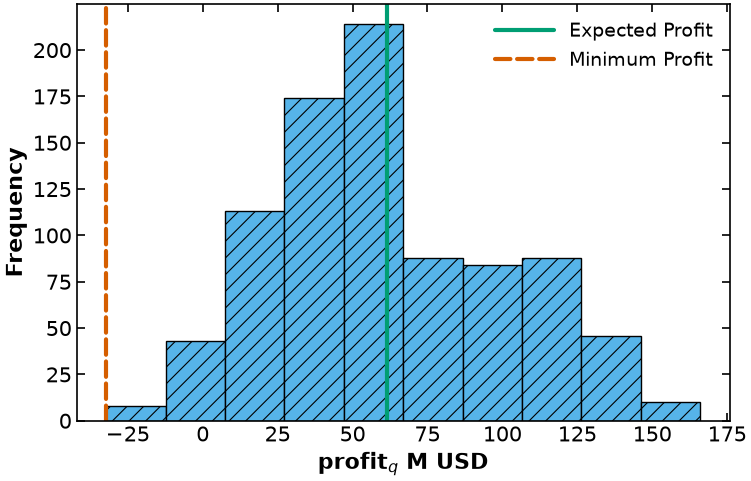

Results
-------------------------------------
Expected Profit: 61.54 M USD
Minimum Profit: -32.17 M USD
Difference: 93.71 M USD


In [18]:
# Collect the profit distribution
profits = []
for i in m.PRICE_SCENARIOS:
    profits.append(pyo.value(m.profit[i]))

# Collect the minimum profit
min_prof = min(profits)

# Plot the Profit Distribution
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.hist(np.array(profits) / 1e6, color="#56B4E9", edgecolor="black", hatch="//")
plt.axvline(
    x=pyo.value(m.expected_profit) / 1e6,
    label="Expected Profit",
    color="#009E73",
    linestyle="solid",
)
plt.axvline(
    x=min_prof / 1e6,
    label=("Minimum Profit"),
    color="#D55E00",
    linestyle="dashed",
)
plt.xlabel("profit$_q$ M USD", fontsize=16, fontweight="bold")
plt.ylabel("Frequency", fontsize=16, fontweight="bold")
plt.legend(fontsize=14)
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

print("Results")
print("-------------------------------------")
print("Expected Profit:", np.round(pyo.value(m.expected_profit) / 1e6, 2), "M USD")
print("Minimum Profit:", np.round(min_prof / 1e6, 2), "M USD")
difference = pyo.value(m.expected_profit) - min_prof
print("Difference:", np.round(difference / 1e6, 2), "M USD")

# Collect results for conclusion
final_EP["MAD"] = pyo.value(m.expected_profit) / 1e6
final_min["MAD"] = min_prof / 1e6
final_diff["MAD"] = difference / 1e6
final_exposure["MAD"] = {c: pyo.value(m.exposure[c]) for c in m.COMMODITIES}
final_profits["MAD"] = np.array(profits)

**Product Distribution**

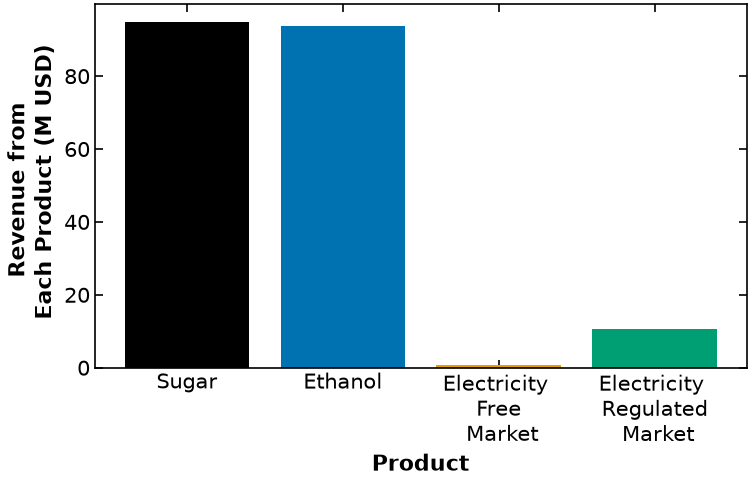

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.bar("Sugar", pyo.value(m.avg_sug_prof) / 1e6)
plt.bar("Ethanol", pyo.value(m.avg_eth_prof) / 1e6)
plt.bar("Electricity \n Free \n Market", pyo.value(m.avg_el_prof) / 1e6)
plt.bar("Electricity \n Regulated \n Market", pyo.value(m.amount["reg"]) * 72.5 / 1e6)
plt.xlabel("Product", fontsize=16, fontweight="bold")
plt.ylabel("Revenue from \n Each Product (M USD)", fontsize=16, fontweight="bold")
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

### Formulate the CVaR Objective

***Additional Parameters***
\begin{align*}
\alpha: Confidence\ Level 
\end{align*}

***Additional Variables***
\begin{align*}
\nu: \text{auxiliary profit threshold} \\
shortfall_{q}: Shortfall \ below \ threshold \ and \ profit_{q} \ at \ price \ scenario \ q\\
\end{align*}

***Additional Constraints***
\begin{align*}
shortfall_{q} \ \geq \ 0 \ \ \forall \ \ q \in Q \\
profit_{q} + shortfall_{q} - \nu \geq 0 \ \ \forall \ \ q \in Q \\
CVaR = \nu - \left[ \frac{1}{Q(1-\alpha)} \sum_{q \in Q} shortfall_{q} \right] \\
Eprofit \geq \rho
\end{align*}

***CVaR Objective***
\begin{align*}
\max{CVaR}
\end{align*}

The lower-tail profit CVaR formulation is an LP here, so use HiGHS. It does not require a user-supplied initial point. Earlier Ipopt failures in this notebook were solver-specific observations, not evidence that scenario risk models generally require initialization or that LICQ alone explains those failures. The deliberate units-error demonstration above remains separate.

In [20]:
# Lower-tail profit CVaR equals minus upper-tail CVaR of loss = -profit.
# The threshold can be nonunique; it need not be the lower-quantile VaR.
# Reload the base Model
m = create_model()

# Add parameters
alpha = 0.9  # confidence level

# Build the LP directly; HiGHS does not need a starting point.

# Add variables
m.shortfall = pyo.Var(m.PRICE_SCENARIOS, domain=pyo.NonNegativeReals, units=u.USD)
m.profit_threshold = pyo.Var(units=u.USD)
m.cvar_profit = pyo.Var(units=u.USD)


# Add CVaR Constraints
@m.Constraint()
def cvar1eq(b):
    return b.cvar_profit == b.profit_threshold - (
        (1 / (b.n_scenarios * (1 - alpha)))
        * sum(b.shortfall[q] for q in b.PRICE_SCENARIOS)
    )


@m.Constraint(m.PRICE_SCENARIOS)
def cvar4eq(b, q):
    return b.profit[q] + b.shortfall[q] - b.profit_threshold >= 0


# The epsilon-constraint: this portfolio must earn at least rho in expectation
add_required_return(m, rho_required)


# OBJECTIVE
@m.Objective(sense=pyo.maximize)
def objective(b):
    return b.cvar_profit


assert_units_consistent(m)

# Solve the LP
sol = pyo.SolverFactory("appsi_highs")
results = sol.solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print("Results")
print("------------------------------")
print("CVaR", np.round(pyo.value(m.cvar_profit), 2), "USD")
print("Optimal profit threshold", np.round(pyo.value(m.profit_threshold), 2), "USD")
print("Expected Profit", np.round(pyo.value(m.expected_profit), 2), "USD")
print("Required Return", np.round(rho_required, 2), "USD")
print("Ethanol Produced", np.round(pyo.value(m.amount["eth"]), 2), "m3")
print("Sugar Produced", np.round(pyo.value(m.amount["sug"]), 2), "tonne")
print("Electricity Produced", np.round(pyo.value(m.amount["el-r"]), 2), "MWh")
print("Electricity to Free Market", np.round(pyo.value(m.amount["fre"]), 2), "MWh")
print("Electricity to Regulated Market", np.round(pyo.value(m.amount["reg"]), 2), "MWh")

Results
------------------------------
CVaR 4423136.02 USD
Optimal profit threshold 15088239.22 USD
Expected Profit 63816117.69 USD
Required Return 61541577.97 USD
Ethanol Produced 155062.24 m3
Sugar Produced 189129.78 tonne
Electricity Produced 159000.0 MWh
Electricity to Free Market 0.0 MWh
Electricity to Regulated Market 159000.0 MWh


### Visualize Results

**Profit Distribution**

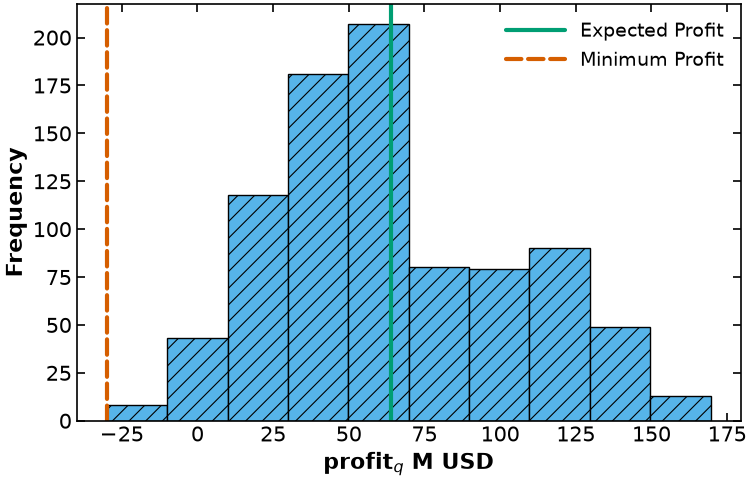

Results
-------------------------------------
Expected Profit: 63.82 M USD
Minimum Profit: -29.94 M USD
Difference: 93.76 M USD


In [21]:
# Collect the profit distribution
profits = []
for i in m.PRICE_SCENARIOS:
    profits.append(pyo.value(m.profit[i]))

# Collect the minimum profit
min_prof = min(profits)

# Plot the Profit Distribution
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.hist(np.array(profits) / 1e6, color="#56B4E9", edgecolor="black", hatch="//")
plt.axvline(
    x=pyo.value(m.expected_profit) / 1e6,
    label="Expected Profit",
    color="#009E73",
    linestyle="solid",
)
plt.axvline(
    x=min_prof / 1e6,
    label=("Minimum Profit"),
    color="#D55E00",
    linestyle="dashed",
)
plt.xlabel("profit$_q$ M USD", fontsize=16, fontweight="bold")
plt.ylabel("Frequency", fontsize=16, fontweight="bold")
plt.legend(fontsize=14)
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

print("Results")
print("-------------------------------------")
print("Expected Profit:", np.round(pyo.value(m.expected_profit) / 1e6, 2), "M USD")
print("Minimum Profit:", np.round(min_prof / 1e6, 2), "M USD")
difference = pyo.value(m.expected_profit) - min_prof
print("Difference:", np.round(difference / 1e6, 2), "M USD")

# Collect results for conclusion
final_EP["CVaR"] = pyo.value(m.expected_profit) / 1e6
final_min["CVaR"] = min_prof / 1e6
final_diff["CVaR"] = difference / 1e6
final_exposure["CVaR"] = {c: pyo.value(m.exposure[c]) for c in m.COMMODITIES}
final_profits["CVaR"] = np.array(profits)

**Product Distribution**

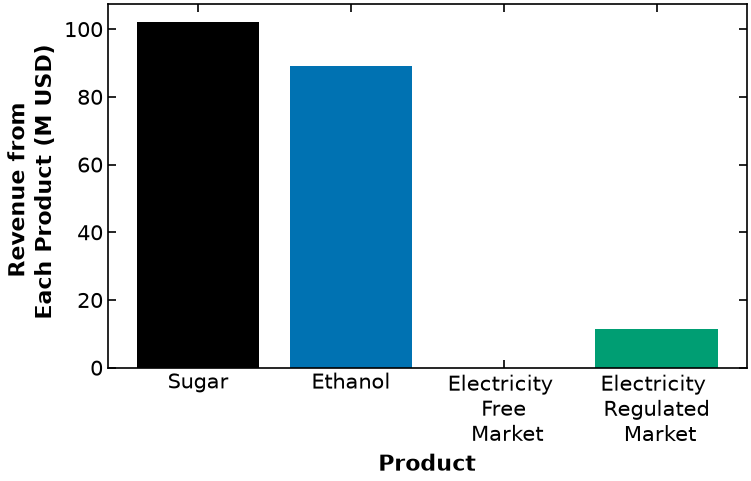

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
plt.bar("Sugar", pyo.value(m.avg_sug_prof) / 1e6)
plt.bar("Ethanol", pyo.value(m.avg_eth_prof) / 1e6)
plt.bar("Electricity \n Free \n Market", pyo.value(m.avg_el_prof) / 1e6)
plt.bar("Electricity \n Regulated \n Market", pyo.value(m.amount["reg"]) * 72.5 / 1e6)
plt.ylabel("Revenue from \n Each Product (M USD)", fontsize=16, fontweight="bold")
plt.xlabel("Product", fontsize=16, fontweight="bold")
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

## Sample the risk–return tradeoffs

For each measure, solve the minimum-risk model, then sample nine expected-profit floors up to the common maximum. This finite sweep is an illustration, not a proof that every Pareto point has been found. Degenerate optima can require tie-breaking.

The horizontal quantities have a common currency unit but different meanings: standard deviation of the return-shock proxy, MAD of that proxy, and CVaR of scenario loss. Compare each curve internally. The common vertical quantity is expected profit under the price-level scenarios.

In [23]:
# The three models again, wrapped as functions of rho so they can be called in
# a loop. Nothing here is new: these are the same three models solved above.
def build_mv(rho=None):
    """Build the mean-variance model, optionally with a required return.

    Args:
        rho: required expected profit [USD], or None for no constraint

    Returns:
        a Pyomo ConcreteModel, not yet solved
    """
    m = create_model()
    if rho is not None:
        add_required_return(m, rho)
    m.objective = pyo.Objective(
        expr=sum(
            m.exposure[i] * covar.loc[i, j] * m.exposure[j]
            for i in m.COMMODITIES
            for j in m.COMMODITIES
        ),
        sense=pyo.minimize,
    )
    return m


def build_mad(rho=None):
    """Build the mean-absolute-deviation model, optionally with a required return.

    Args:
        rho: required expected profit [USD], or None for no constraint

    Returns:
        a Pyomo ConcreteModel, not yet solved
    """
    m = create_model()
    initialize_from_max_profit(m)

    m.RETURN_OBSERVATIONS = pyo.Set(initialize=J)
    m.y_aux = pyo.Var(m.RETURN_OBSERVATIONS, domain=pyo.NonNegativeReals, units=u.USD)
    m.z_aux = pyo.Var(m.RETURN_OBSERVATIONS, domain=pyo.NonNegativeReals, units=u.USD)

    @m.Constraint(m.RETURN_OBSERVATIONS)
    def aux(b, j):
        return b.y_aux[j] - b.z_aux[j] == sum(
            b.exposure[i] * (price_returns.loc[j, i] - mean_return[i])
            for i in b.COMMODITIES
        )

    for j in J:
        dev = sum(
            pyo.value(m.exposure[i]) * (price_returns.loc[j, i] - mean_return[i])
            for i in m.COMMODITIES
        )
        m.y_aux[j].set_value(max(0.0, dev))
        m.z_aux[j].set_value(max(0.0, -dev))

    if rho is not None:
        add_required_return(m, rho)

    m.objective = pyo.Objective(
        expr=(1 / n_returns) * sum(m.y_aux[j] + m.z_aux[j] for j in J),
        sense=pyo.minimize,
    )
    return m


def build_cvar(rho=None):
    """Build the CVaR model, optionally with a required return.

    Args:
        rho: required expected profit [USD], or None for no constraint

    Returns:
        a Pyomo ConcreteModel, not yet solved
    """
    m = create_model()
    initialize_from_max_profit(m)

    m.shortfall = pyo.Var(m.PRICE_SCENARIOS, domain=pyo.NonNegativeReals, units=u.USD)
    m.profit_threshold = pyo.Var(units=u.USD)
    m.cvar_profit = pyo.Var(units=u.USD)

    m.cvar1eq = pyo.Constraint(
        expr=m.cvar_profit
        == m.profit_threshold
        - (1 / (m.n_scenarios * (1 - alpha)))
        * sum(m.shortfall[q] for q in m.PRICE_SCENARIOS)
    )

    @m.Constraint(m.PRICE_SCENARIOS)
    def cvar4eq(b, q):
        return b.profit[q] + b.shortfall[q] - b.profit_threshold >= 0

    # Optional feasible warm start; HiGHS does not require initialization.
    init_profits = np.array([pyo.value(m.profit[q]) for q in m.PRICE_SCENARIOS])
    nu_init = float(np.percentile(init_profits, 100 * (1 - alpha)))
    m.profit_threshold.set_value(nu_init)
    for q in m.PRICE_SCENARIOS:
        m.shortfall[q].set_value(max(0.0, nu_init - pyo.value(m.profit[q])))
    m.cvar_profit.set_value(
        nu_init
        - sum(pyo.value(m.shortfall[q]) for q in m.PRICE_SCENARIOS)
        / (pyo.value(m.n_scenarios) * (1 - alpha))
    )

    if rho is not None:
        add_required_return(m, rho)

    m.objective = pyo.Objective(expr=m.cvar_profit, sense=pyo.maximize)
    return m

In [24]:
# Each measure reports its risk in its own units. Put all three in M USD and
# orient them so that a smaller number always means less risk.
builders = {"MV": build_mv, "MAD": build_mad, "CVaR": build_cvar}
risk_in_musd = {
    "MV": lambda m: np.sqrt(pyo.value(m.objective)) / 1e6,  # sqrt(MV) [M USD]
    "MAD": lambda m: pyo.value(m.objective) / 1e6,  # MAD [M USD]
    "CVaR": lambda m: -pyo.value(m.cvar_profit) / 1e6,  # CVaR of the loss [M USD]
}

n_points = 9
frontier = {}

for name, build in builders.items():
    sol = pyo.SolverFactory("ipopt" if name == "MV" else "appsi_highs")
    # Lower anchor: the minimum-risk portfolio, with no required return imposed
    m_anchor = build()
    results = sol.solve(m_anchor)
    assert pyo.check_optimal_termination(results), (
        f"{name} minimum-risk solve failed: "
        f"termination={results.solver.termination_condition}"
    )
    risks = [risk_in_musd[name](m_anchor)]
    returns = [pyo.value(m_anchor.expected_profit) / 1e6]

    # Sweep rho from that anchor up to the maximum attainable expected profit
    for rho in np.linspace(pyo.value(m_anchor.expected_profit), EP_max, n_points)[1:]:
        m_rho = build(rho)
        results = sol.solve(m_rho)
        assert pyo.check_optimal_termination(results), (
            f"{name} sweep failed at rho = {rho / 1e6:.3f} M USD: "
            f"termination={results.solver.termination_condition}"
        )
        risks.append(risk_in_musd[name](m_rho))
        returns.append(pyo.value(m_rho.expected_profit) / 1e6)

    frontier[name] = (risks, returns)
    print(
        f"{name:5s} risk {risks[0]:8.4f} -> {risks[-1]:8.4f} M USD   "
        f"expected profit {returns[0]:7.3f} -> {returns[-1]:7.3f} M USD"
    )

MV    risk   5.3870 ->   6.4439 M USD   expected profit  60.157 ->  64.781 M USD


MAD   risk   3.5831 ->   4.5157 M USD   expected profit  53.349 ->  64.781 M USD


CVaR  risk  -4.4231 ->   0.1173 M USD   expected profit  63.816 ->  64.781 M USD


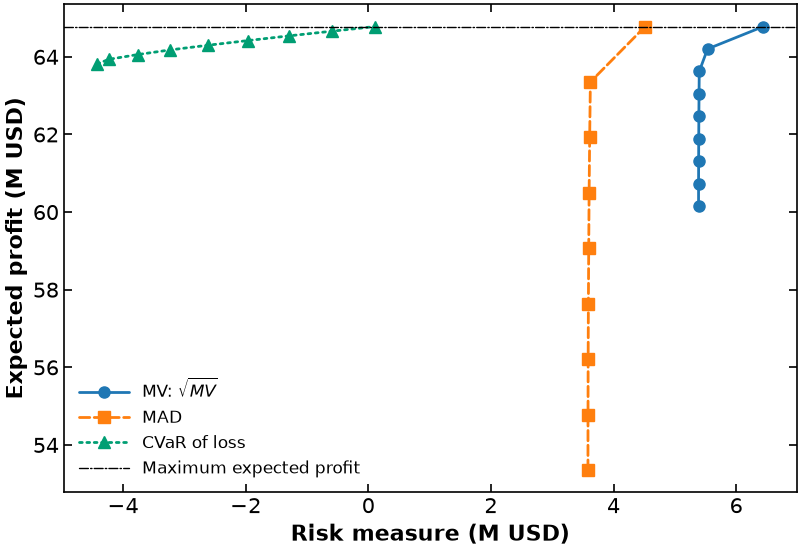

In [25]:
# Colour AND linestyle AND marker: the handouts get printed in black and white,
# so no distinction here is carried by colour alone.
fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")
ax.plot(
    frontier["MV"][0],
    frontier["MV"][1],
    color="tab:blue",
    linestyle="-",
    marker="o",
    linewidth=2,
    label="MV: $\\sqrt{MV}$",
)
ax.plot(
    frontier["MAD"][0],
    frontier["MAD"][1],
    color="tab:orange",
    linestyle="--",
    marker="s",
    linewidth=2,
    label="MAD",
)
ax.plot(
    frontier["CVaR"][0],
    frontier["CVaR"][1],
    color="#009E73",
    linestyle=":",
    marker="^",
    linewidth=2,
    label="CVaR of loss",
)
ax.axhline(
    EP_max / 1e6,
    color="black",
    linestyle="-.",
    linewidth=1,
    label="Maximum expected profit",
)
ax.set_xlabel("Risk measure (M USD)", fontsize=16, fontweight="bold")
ax.set_ylabel("Expected profit (M USD)", fontsize=16, fontweight="bold")
ax.legend(fontsize=12)
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.show()

Read the computed tables and curves together. The MV and MAD objectives measure return-shock dispersion on mean-price exposures; the CVaR objective measures the lower tail of scenario profit. Their horizontal coordinates are therefore not directly comparable. The curves share the maximum expected-profit level, not necessarily one plotted point or a unique decision vector.

These are in-sample calculations with a fixed production model. A kink alone does not identify which constraint becomes active; inspect constraint slacks before attributing it to a particular capacity.

## Conclusion

### Final Results Comparison

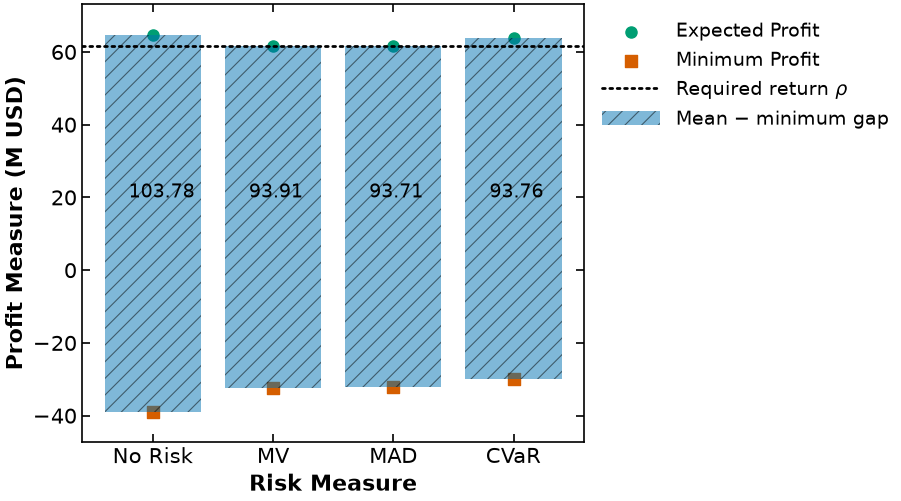

In [26]:
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
k = 0
for i in final_EP.keys():
    if k < 0.5:
        plt.scatter(
            i, final_EP[i], color="#009E73", marker="o", label="Expected Profit"
        )
        plt.scatter(
            i, final_min[i], color="#D55E00", marker="s", label="Minimum Profit"
        )
        plt.bar(
            i,
            final_diff[i],
            color="#0072B2",
            alpha=0.5,
            bottom=final_min[i],
            hatch="//",
            label="Mean − minimum gap",
        )
        plt.text(k - 0.2, 20, np.round(final_diff[i], 2), fontsize=14)
    else:
        plt.scatter(i, final_EP[i], color="#009E73", marker="o")
        plt.scatter(i, final_min[i], color="#D55E00", marker="s")
        plt.bar(
            i,
            final_diff[i],
            color="#0072B2",
            alpha=0.5,
            bottom=final_min[i],
            hatch="//",
        )
        plt.text(k - 0.2, 20, np.round(final_diff[i], 2), fontsize=14)
    k = k + 1

plt.axhline(
    rho_required / 1e6,
    color="black",
    linestyle="dotted",
    linewidth=2,
    label="Required return $\\rho$",
)

ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.tick_params(direction="in")
plt.legend(bbox_to_anchor=(1, 1), fontsize=14)
plt.xlabel("Risk Measure", fontsize=16, fontweight="bold")
plt.ylabel("Profit Measure (M USD)", fontsize=16, fontweight="bold")
# Leave room below the bars so minimum-profit markers remain visible.
span = max(final_EP.values()) - min(final_min.values())
ax.set_ylim(min(final_min.values()) - 0.08 * span, max(final_EP.values()) + 0.08 * span)
plt.show()

### Every Portfolio, Measured Every Way

The figure above compares the four portfolios on the same two profit statistics. A sharper question is how each portfolio scores under the *other* measures' definitions of risk, since a portfolio that is best under MV is not automatically good under CVaR. The table below evaluates all three risk measures on all four portfolios.

In [27]:
def portfolio_risk(exposure, profits, alpha):
    """Evaluate all three risk measures on one portfolio.

    Args:
        exposure: dict of monetary exposure w_c by commodity [USD]
        profits: array of profit_q over the price scenarios [USD]
        alpha: CVaR confidence level

    Returns:
        (sqrt(MV), MAD, CVaR of the loss), all in USD
    """
    w = np.array([exposure[c] for c in covar.columns])
    sigma = np.sqrt(w @ covar.to_numpy() @ w)

    # Deviation of the portfolio return from its mean, in USD, per observation
    R = price_returns[list(covar.columns)].iloc[1:]
    mad = np.abs((R - R.mean()).to_numpy() @ w).mean()

    # Empirical CVaR of the loss = min over nu of nu + E[(loss - nu)+]/(1 - alpha).
    # At least one minimizer is an observed loss; an entire interval may minimize.
    loss = -np.asarray(profits)
    cvar = min(nu + np.maximum(loss - nu, 0.0).mean() / (1 - alpha) for nu in loss)

    return sigma, mad, cvar


rows = []
for name in final_EP:
    sigma, mad, cvar = portfolio_risk(final_exposure[name], final_profits[name], alpha)
    rows.append(
        {
            "Objective": name,
            "E[profit]": final_EP[name],
            "sqrt(MV)": sigma / 1e6,
            "MAD": mad / 1e6,
            "CVaR of loss": cvar / 1e6,
            "Min profit": final_min[name],
        }
    )

summary = pd.DataFrame(rows).set_index("Objective").round(4)
print("All values in M USD. Smaller is less risk in the three risk columns.")
print("---------------------------------------------------------------------")
print(summary.to_string())

All values in M USD. Smaller is less risk in the three risk columns.
---------------------------------------------------------------------
           E[profit]  sqrt(MV)     MAD  CVaR of loss  Min profit
Objective                                                       
No Risk      64.7806    6.4439  4.5157        0.1173    -39.0034
MV           61.5416    5.3888  3.6118       -3.1634    -32.3643
MAD          61.5416    5.3894  3.6085       -3.2252    -32.1660
CVaR         63.8161    5.4108  3.6312       -4.4231    -29.9420


Each risk-optimized portfolio should attain its own best objective among feasible alternatives under the same profit floor, up to numerical tolerance; ties are possible. The table checks all portfolios under each definition. Similar numbers do not establish that two risk measures are equivalent.

CVaR uses the worst 10% of scenario **probability mass**, not ten percent of calendar years. Each historical price row is applied to a full year's fixed production. These in-sample portfolios do not establish out-of-sample market performance.

### Discussion questions

* Which assumptions differ between the MV/MAD proxy and scenario-profit CVaR?
* Is the required-profit constraint active for each optimized portfolio?
* How would you evaluate a selected portfolio on held-out price data?


## References

<div class="csl-entry"> [1] Gunjan, A., &#38; Bhattacharyya, S. (2022). A brief review of portfolio optimization techniques. <i>Artificial Intelligence Review</i>. https://doi.org/10.1007/s10462-022-10273-7</div>

<div class="csl-entry"> [2] Markowitz, H. (1959). Portfolio selection, efficient diversification of investments. Wiley, New York</div>

<div class="csl-entry"> [3] Konno, H., &#38; Koshizuka, T. (2005). Mean-absolute deviation model. <i>IIE Transactions (Institute of Industrial Engineers)</i>, <i>37</i>(10), 893–900. https://doi.org/10.1080/07408170591007786</div>

<div class="csl-entry"> [4] Mutran, V. M., Ribeiro, C. O., Nascimento, C. A. O., &#38; Chachuat, B. (2020). Risk-conscious optimization model to support bioenergy investments in the Brazilian sugarcane industry. <i>Applied Energy</i>, <i>258</i>. https://doi.org/10.1016/j.apenergy.2019.113978</div>

<div class="csl-entry"> [5] Li, L., Lin, J., Wu, N., Xie, S., Meng, C., Zheng, Y., Wang, X., &#38; Zhao, Y. (2022). Review and outlook on the international renewable energy development. In <i>Energy and Built Environment</i> (Vol. 3, Issue 2, pp. 139–157). KeAi Communications Co. https://doi.org/10.1016/j.enbenv.2020.12.002</div>

<div class="csl-entry"> [6] Oliveira, S. M. de, Ribeiro, C. de O., &#38; Cicogna, M. P. V. (2018). Uncertainty effects on production mix and on hedging decisions: The case of Brazilian ethanol and sugar. <i>Energy Economics</i>, <i>70</i>, 516–524. https://doi.org/10.1016/j.eneco.2018.01.025</div>

Primary sources used for the definitions above:

* Markowitz (1952), *Portfolio Selection*, [DOI](https://doi.org/10.1111/j.1540-6261.1952.tb01525.x).
* Konno and Yamazaki (1991), *Mean-Absolute Deviation Portfolio Optimization Model and Its Applications to Tokyo Stock Market*, [primary PDF](https://web.stanford.edu/class/msande348/papers/Konno_MeanAbDev_ManSciMay91.pdf).
* Rockafellar and Uryasev (2002), *Conditional Value-at-Risk for General Loss Distributions*, [author preprint](https://sites.math.washington.edu/~rtr/papers/rtr187-CVaR2.pdf).

The literature-example lists are optional further reading; their published results are not reproduced here.
